## Gerando a base de dados

In [21]:
import numpy as np
import pandas as pd

def gerar_dados_xenoverse_10_colunas(n=3000, semente=42):
    rng = np.random.default_rng(semente)

    # Id
    id_patrulheiro = [f"PT-{i:04d}" for i in range(1, n + 1)]

    # Nível do personagem (1 a 199)
    nivel = rng.normal(70, 20, n).clip(1, 199).round().astype(int)

    # Tempo de jogo em horas
    tempo_jogo_horas = (nivel * rng.uniform(1.5, 3.5, n) + rng.normal(0, 15, n)).clip(5, 500).round(1)

    # Medalhas PT
    medalhas_pt = rng.lognormal(mean=6.2, sigma=0.6, size=n)
    idx_outlier = rng.choice(n, size=15, replace=False)
    medalhas_pt[idx_outlier] *= rng.uniform(5, 12, size=15)
    medalhas_pt = medalhas_pt.round().astype(int)

    # Raças
    racas = np.array(["Saiyan", "Human", "Majin", "Namekian", "Frieza"])
    raca = rng.choice(racas, size=n, p=[0.45, 0.25, 0.12, 0.08, 0.10])

    # Taxa de sucesso em missões (%)
    quest_sucess = (20 + 0.4 * nivel + rng.normal(0, 8, n)).clip(20, 100).round(2)

    # Ki Máximo (0 a 200)
    ki_maximo = (rng.normal(30, 40, n) + (nivel * 0.8)).clip(0, 200).round().astype(int)

    # Stamina Máxima (0 a 200)
    stamina_maxima = (rng.normal(30, 40, n) + (nivel * 0.7)).clip(0, 200).round().astype(int)

    # Mentor Atual
    mentores = np.array(["krillin", "tien", "yamcha", "piccolo", "raditz", "gohan (kid)", "nappa", "vegeta", "zarbon", "dodoria", "captain ginyu", "frieza", "cooler", "android 18", "android 16", "cell", "lord slug", "majin buu", "hercule", "gohan (adult) and videl", "gotenks", "turles", "broly", "beerus", "whis", "pan", "jaco", "goku", "gohan (future)","bardock", "hit", "bojack", "zamasu", "nenhum",])
    p_raw = np.arange(len(mentores), 0, -1)
    p = p_raw / np.sum(p_raw)
    mentor_atual = rng.choice(mentores, size=n, p=p)

    # Criando o DataFrame Limpo
    df_limpo = pd.DataFrame({
        "id_patrulheiro": id_patrulheiro,
        "nivel": nivel,
        "tempo_jogo_horas": tempo_jogo_horas,
        "medalhas_pt": medalhas_pt,
        "raca": raca,
        "quest_sucess": quest_sucess,
        "ki_maximo": ki_maximo,
        "stamina_maxima": stamina_maxima,
        "mentor_atual": mentor_atual
    })

    # 2. Criando a versão suja
    df_sujo = df_limpo.copy()

    # Inserindo valores nulos (NaN) em várias colunas
    mask_nivel = rng.uniform(0, 1, n) < 0.05
    mask_medalhas = rng.uniform(0, 1, n) < 0.08
    mask_raca = rng.uniform(0, 1, n) < 0.04
    mask_ki = rng.uniform(0, 1, n) < 0.03
    mask_stamina = rng.uniform(0, 1, n) < 0.03

    df_sujo.loc[mask_nivel, "nivel"] = np.nan
    df_sujo.loc[mask_medalhas, "medalhas_pt"] = np.nan
    df_sujo.loc[mask_raca, "raca"] = np.nan
    df_sujo.loc[mask_ki, "ki_maximo"] = np.nan
    df_sujo.loc[mask_stamina, "stamina_maxima"] = np.nan

    # Inserindo níveis inválidos (negativos ou acima de 199) em ~3% dos dados válidos
    idx_nivel_ruim = rng.choice(n, size=int(n * 0.03), replace=False)
    valores_invalidos_nivel = rng.choice([-5, -1, 0, 250, 300, 999], size=len(idx_nivel_ruim))
    df_sujo.loc[idx_nivel_ruim, "nivel"] = valores_invalidos_nivel

    # Inserindo medalhas negativas em alguns registros
    idx_medalhas_negativas = rng.choice(n, size=20, replace=False)
    df_sujo.loc[idx_medalhas_negativas, "medalhas_pt"] = rng.integers(-500, -1, size=20)

    # --- SUJEIRA EM STRINGS (Espaços aleatórios e formatação) ---
    def sujar_espacos(texto):
        if pd.isna(texto):
            return texto
        espacos_inicio = " " * rng.integers(1, 4) if rng.random() > 0.5 else ""
        espacos_fim = " " * rng.integers(1, 4) if rng.random() > 0.5 else ""
        return f"{espacos_inicio}{texto}{espacos_fim}"

    mask_txt = rng.uniform(0, 1, n) < 0.25
    df_sujo.loc[mask_txt, "raca"] = df_sujo.loc[mask_txt, "raca"].apply(sujar_espacos)
    mask_txt_mentor = rng.uniform(0, 1, n) < 0.20
    df_sujo.loc[mask_txt_mentor, "mentor_atual"] = df_sujo.loc[mask_txt_mentor, "mentor_atual"].apply(sujar_espacos)

    # --- DUPLICAÇÃO DE LINHAS ---
    # Escolhe aleatoriamente por volta de 3% a 5% de linhas para duplicar
    qtd_duplicadas = int(n * 0.04)
    linhas_para_duplicar = df_sujo.sample(n=qtd_duplicadas, random_state=rng.integers(0, 10000))
    df_sujo = pd.concat([df_sujo, linhas_para_duplicar], ignore_index=True)

    # Salvando os arquivos em CSV
    df_limpo.to_csv("DBXV2_limpo.csv", index=False)
    df_sujo.to_csv("DBXV2_sujo.csv", index=False)

    print(f"Total limpo: {n} registros | Total sujo (com duplicadas): {len(df_sujo)} registros | Total de colunas: {df_sujo.shape[1]}")
    return df_limpo, df_sujo

# Executando a função
df_limpo, df_sujo = gerar_dados_xenoverse_10_colunas()

Total limpo: 3000 registros | Total sujo (com duplicadas): 3120 registros | Total de colunas: 9


## Aplicando o Tratamento

In [22]:
# Importações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

In [23]:
# Carregando a base de dados
df = pd.read_csv("DBXV2_sujo.csv")
print("Formato do dataset (linhas, colunas):", df.shape)
df.head()

Formato do dataset (linhas, colunas): (3120, 9)


,id_patrulheiro,nivel,tempo_jogo_horas,medalhas_pt,raca,quest_sucess,ki_maximo,stamina_maxima,mentor_atual
0,PT-0001,76.0,269.4,413.0,Saiyan,57.03,94.0,165.0,dodoria
1,PT-0002,49.0,156.0,326.0,Human,27.95,47.0,66.0,tien
2,PT-0003,85.0,258.4,840.0,Namekian,46.13,150.0,109.0,lord slug
3,PT-0004,89.0,277.8,210.0,Namekian,58.26,85.0,NaN,tien
4,PT-0005,31.0,99.1,271.0,Human,27.43,0.0,87.0,vegeta


In [24]:
# Mostra tipos de coluna e quais têm valores não nulos
df.info()

# Quantidade de valores ausentes por coluna
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_patrulheiro    3120 non-null   str    
 1   nivel             2964 non-null   float64
 2   tempo_jogo_horas  3120 non-null   float64
 3   medalhas_pt       2872 non-null   float64
 4   raca              2989 non-null   str    
 5   quest_sucess      3120 non-null   float64
 6   ki_maximo         3024 non-null   float64
 7   stamina_maxima    3034 non-null   float64
 8   mentor_atual      3120 non-null   str    
dtypes: float64(6), str(3)
memory usage: 219.5 KB


id_patrulheiro        0
nivel               156
tempo_jogo_horas      0
medalhas_pt         248
raca                131
quest_sucess          0
ki_maximo            96
stamina_maxima       86
mentor_atual          0
dtype: int64

In [25]:
# Ideia geral da escala e possíveis aberrações
df.describe()

,nivel,tempo_jogo_horas,medalhas_pt,quest_sucess,ki_maximo,stamina_maxima
count,2964.000000,3120.000000,2872.000000,3120.000000,3024.000000,3034.000000
mean,76.619771,172.605833,599.450209,48.089968,87.858796,80.055043
std,78.477537,67.051569,670.310070,11.349973,42.227385,40.366152
min,-5.000000,5.000000,-495.000000,20.000000,0.000000,0.000000
25%,56.000000,123.300000,317.750000,40.400000,58.750000,52.000000
50%,70.000000,166.350000,477.000000,48.095000,88.000000,80.000000
75%,83.000000,215.800000,730.000000,55.900000,117.000000,106.000000
max,999.000000,436.400000,24646.000000,87.660000,200.000000,200.000000


In [26]:
# Removendo duplicatas caso haja
print(df.shape)
df = df.drop_duplicates(subset='id_patrulheiro', keep='first')
print(df.shape)

(3120, 9)
(3000, 9)


In [27]:
# Removendo espaços
colunas_texto = df.select_dtypes(include=['object', 'string']).columns
for col in colunas_texto:
    df[col] = df[col].str.strip()

In [28]:
# Removendo valores absurdos
# Nivel precisa ser entre 1 e 199
df.loc[(df['nivel'] <= 0) | (df['nivel'] > 199), 'nivel'] = np.nan

# Medalhas pt não podem ser negativas
df.loc[df['medalhas_pt'] < 0, 'medalhas_pt'] = np.nan

# Tratar ki e stamina entre 0 e 200
df.loc[(df['ki_maximo'] < 0) | (df['ki_maximo'] > 200), 'ki_maximo'] = np.nan
df.loc[(df['stamina_maxima'] < 0) | (df['stamina_maxima'] > 200), 'stamina_maxima'] = np.nan

In [29]:
# Separando colunas
colunas_features = [
    "nivel",
    "tempo_jogo_horas",
    "raca",
    "quest_sucess",
    "ki_maximo",
    "stamina_maxima",
]
X = df[colunas_features].copy()
mentor = df["mentor_atual"]

In [30]:
# Separando test e treino
X_train, X_test, ref_train, ref_test = train_test_split(
    X, mentor,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=mentor,
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)

Treino: (2100, 6)  Teste: (900, 6)


In [31]:
# Cria uma variavel para as colunas numericas
colunas_num = ["nivel", "tempo_jogo_horas", "quest_sucess", "ki_maximo", "stamina_maxima"]

# Preencher NaN numérico
imputer = SimpleImputer(strategy="median")
X_train_imputado = pd.DataFrame(
    imputer.fit_transform(X_train[colunas_num]),
    columns=colunas_num,
    index=X_train.index,
)

X_test_imputado = pd.DataFrame(
    imputer.transform(X_test[colunas_num]),
    columns=colunas_num,
    index=X_test.index,
)

# Preencher NaN das racas
imputer2 = SimpleImputer(strategy="most_frequent")
X_train_imputado2 = pd.DataFrame(
    imputer2.fit_transform(X_train[["raca"]]),
    columns=["raca"],
    index=X_train.index,
)

X_test_imputado2 = pd.DataFrame(
    imputer2.transform(X_test[["raca"]]),
    columns=["raca"],
    index=X_test.index,
)


In [32]:
# Transforma a raça em valores de 0 a 1
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Treina e aplica na base de treino
X_train_enc = pd.DataFrame(
    encoder.fit_transform(X_train_imputado2),
    columns=encoder.get_feature_names_out(["raca"]),
    index=X_train_imputado2.index
)

# Apenas aplica na base de teste
X_test_enc = pd.DataFrame(
    encoder.transform(X_test_imputado2),
    columns=encoder.get_feature_names_out(["raca"]),
    index=X_test_imputado2.index
)

# Juntando as tabelas numéricas com as novas colunas de raça
X_train_completo = pd.concat([X_train_imputado, X_train_enc], axis=1)
X_test_completo = pd.concat([X_test_imputado, X_test_enc], axis=1)


In [33]:
# Padronização de todas as variáveis
scaler = StandardScaler()

# Ajusta a escala e centraliza os dados (Treino))
X_train_final = pd.DataFrame(
    scaler.fit_transform(X_train_completo),
    columns=X_train_completo.columns,
    index=X_train_completo.index
)

# Aplica a mesma escala nos dados "novos" (Teste)
X_test_final = pd.DataFrame(
    scaler.transform(X_test_completo),
    columns=X_test_completo.columns,
    index=X_test_completo.index
)


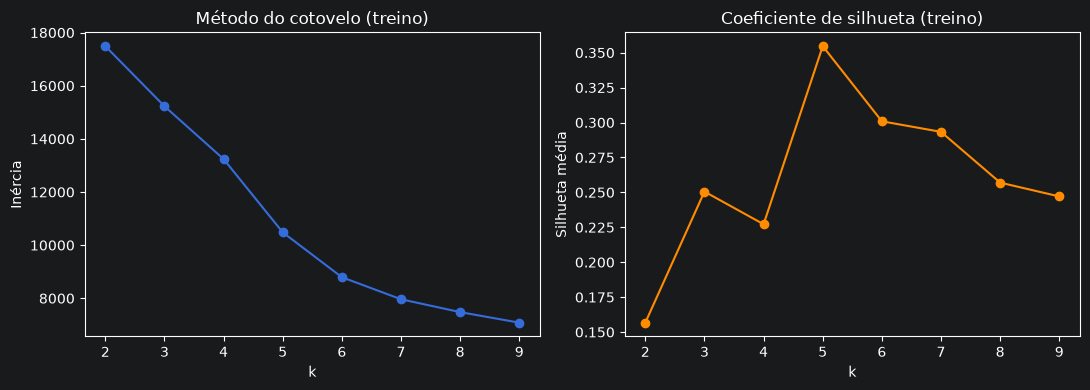

In [34]:
# Escolher o melhor k
valores_k = range(2, 10)
inercias = []
silhuetas = []

for k in valores_k:
    modelo_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = modelo_k.fit_predict(X_train_final)
    inercias.append(modelo_k.inertia_)
    silhuetas.append(silhouette_score(X_train_final, labels_k))

# Gera os graficos
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set_title("Método do cotovelo (treino)")
eixos[0].set_xlabel("k")
eixos[0].set_ylabel("Inércia")

eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set_title("Coeficiente de silhueta (treino)")
eixos[1].set_xlabel("k")
eixos[1].set_ylabel("Silhueta média")
plt.tight_layout()
plt.show()


In [35]:
# Testando vários vizinhos (k) para achar a melhor acurácia
k_values = range(1, 20)
melhor_k = 0
melhor_acc = 0

print("Testando o K-NN:")
for k in k_values:
    # Criando o modelo KNN com o número de vizinhos atual
    knn = KNeighborsClassifier(n_neighbors=k)

    # Treinando o modelo
    knn.fit(X_train_final, ref_train)

    # Pedindo para o modelo adivinhar os mentores da base de teste
    y_pred = knn.predict(X_test_final)

    # Calculando a acurácia (comparando o palpite com o mentor real)
    acc = accuracy_score(ref_test, y_pred)

    print(f"k={k} vizinhos: Acurácia = {acc:.4f}")

    # Guardando a melhor acurácia encontrada
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print("-" * 30)
print(f"Acurácia final (Melhor k={melhor_k}): {melhor_acc:.4f}")

Testando o K-NN:
k=1 vizinhos: Acurácia = 0.0322
k=2 vizinhos: Acurácia = 0.0356
k=3 vizinhos: Acurácia = 0.0356
k=4 vizinhos: Acurácia = 0.0344
k=5 vizinhos: Acurácia = 0.0378
k=6 vizinhos: Acurácia = 0.0356
k=7 vizinhos: Acurácia = 0.0444
k=8 vizinhos: Acurácia = 0.0444
k=9 vizinhos: Acurácia = 0.0478
k=10 vizinhos: Acurácia = 0.0422
k=11 vizinhos: Acurácia = 0.0389
k=12 vizinhos: Acurácia = 0.0400
k=13 vizinhos: Acurácia = 0.0422
k=14 vizinhos: Acurácia = 0.0400
k=15 vizinhos: Acurácia = 0.0400
k=16 vizinhos: Acurácia = 0.0456
k=17 vizinhos: Acurácia = 0.0467
k=18 vizinhos: Acurácia = 0.0500
k=19 vizinhos: Acurácia = 0.0489
------------------------------
Acurácia final (Melhor k=18): 0.0500


In [36]:
# Treinar o K-Means final
K_ESCOLHIDO = 5
modelo_kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
labels_train = modelo_kmeans.fit_predict(X_train_final)

print("Centróides (em espaço padronizado):")
print(modelo_kmeans.cluster_centers_.round(2))


Centróides (em espaço padronizado):
[[ 0.04  0.03  0.02  0.02  0.02 -0.31 -0.55 -0.37 -0.29  1.04]
 [-0.06 -0.07 -0.04 -0.04 -0.02 -0.31  1.81 -0.37 -0.29 -0.96]
 [ 0.    0.01  0.04 -0.   -0.01 -0.31 -0.55  2.73 -0.29 -0.96]
 [ 0.06 -0.02  0.08  0.01 -0.03 -0.31 -0.55 -0.37  3.41 -0.96]
 [-0.11 -0.02 -0.13 -0.03 -0.03  3.21 -0.55 -0.37 -0.29 -0.96]]


Médias de status e raças por Arquétipo de Patrulheiro:


cluster,0,1,2,3,4
nivel,70.01,68.18,69.31,70.45,67.22
tempo_jogo_horas,174.14,167.41,172.76,170.57,170.75
quest_sucess,48.30,47.58,48.49,49.00,46.54
ki_maximo,88.54,86.05,87.54,88.22,86.14
stamina_maxima,80.22,78.35,78.79,78.02,78.06
raca_Frieza,0.00,0.00,0.00,0.00,1.00
raca_Human,0.00,1.00,0.00,0.00,0.00
raca_Majin,0.00,0.00,1.00,0.00,0.00
raca_Namekian,0.00,0.00,0.00,1.00,0.00
raca_Saiyan,1.00,0.00,0.00,0.00,0.00


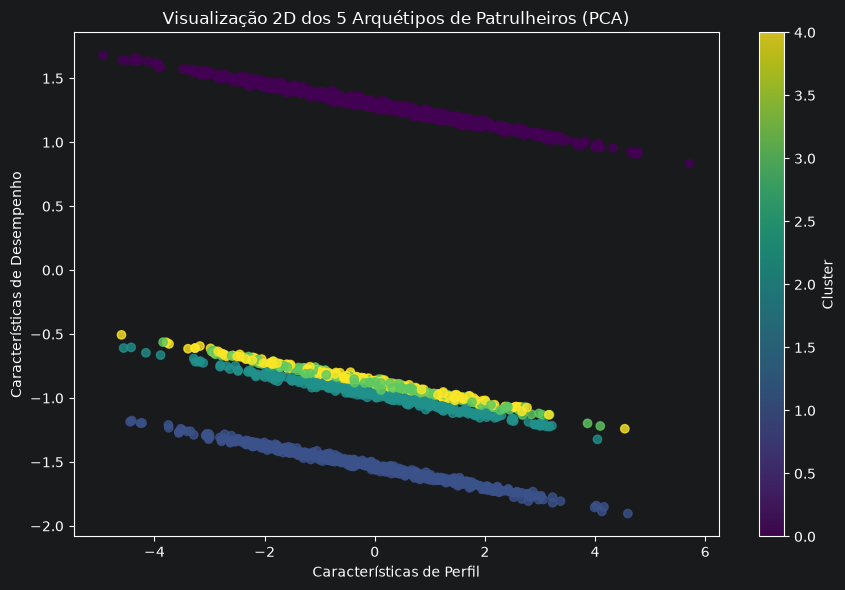

In [37]:
# Gerando o gráfico de espalhamento
X_train_interpretacao = X_train_completo.copy()
X_train_interpretacao["cluster"] = labels_train
resumo = X_train_interpretacao.groupby("cluster").mean().round(2)

print("Médias de status e raças por Arquétipo de Patrulheiro:")
display(resumo.T)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_final)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_train, cmap="viridis", alpha=0.8)

plt.xlabel("Características de Perfil")
plt.ylabel("Características de Desempenho")
plt.title("Visualização 2D dos 5 Arquétipos de Patrulheiros (PCA)")

plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()

In [38]:
# Aplica o modelo treinado no teste
labels_test = modelo_kmeans.predict(X_test_final)

silhueta_treino = silhouette_score(X_train_final, labels_train)
silhueta_teste = silhouette_score(X_test_final, labels_test)
print(f"Silhueta no treino: {silhueta_treino:.3f}")
print(f"Silhueta no teste:  {silhueta_teste:.3f}")

Silhueta no treino: 0.355
Silhueta no teste:  0.358


In [39]:
# Interpretar os grupos com base no treino
X_train_interpretacao = X_train_completo.copy()
X_train_interpretacao["cluster"] = labels_train

# Agrupando e calculando a média de todos os atributos e raças
perfil_dos_grupos = X_train_interpretacao.groupby("cluster").mean().round(2)

# Transpondo (.T) apenas para facilitar a leitura na tela caso haja muitas colunas
print(perfil_dos_grupos.T)

print("\nComparação com o rótulo de referência no TESTE (só para conferência):")
print(pd.crosstab(labels_test, ref_test.values))

cluster                0       1       2       3       4
nivel              70.01   68.18   69.31   70.45   67.22
tempo_jogo_horas  174.14  167.41  172.76  170.57  170.75
quest_sucess       48.30   47.58   48.49   49.00   46.54
ki_maximo          88.54   86.05   87.54   88.22   86.14
stamina_maxima     80.22   78.35   78.79   78.02   78.06
raca_Frieza         0.00    0.00    0.00    0.00    1.00
raca_Human          0.00    1.00    0.00    0.00    0.00
raca_Majin          0.00    0.00    1.00    0.00    0.00
raca_Namekian       0.00    0.00    0.00    1.00    0.00
raca_Saiyan         1.00    0.00    0.00    0.00    0.00

Comparação com o rótulo de referência no TESTE (só para conferência):
col_0  android 16  android 18  bardock  beerus  bojack  broly  captain ginyu  \
row_0                                                                          
0              15           7        3       6       4      8             19   
1               8           6        2       4       0      7 

In [40]:
# Calcula a Acuracia
ari_teste = adjusted_rand_score(ref_test, labels_test)
print(f"ARI (Clusters vs Mentores): {ari_teste:.4f}")

ARI (Clusters vs Mentores): -0.0014
